## Analyzing Bonus Certificates on the Telekom Stock

In the following notebook, we investigate Bonus Certificates linked to the Telekom stock. A Bonus Certificate is a type of structured derivative that offers investors conditional protection against moderate price declines, while still allowing participation in positive performance. We assume that any fraction of the security is tradable and that the risk-free interest rate $r$ is constant at 2% per annum. Our analysis focuses on understanding the product’s payoff structure, modeling its fair price under the Black-Scholes framework, and confirming the analytical price through a Monte Carlo simulation.

In [38]:
r = .02

The necessary Python libraries for numerical computations, data visualization, and financial modeling are imported first.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import skew, kurtosis

## Task 1

We begin by loading the historical closing prices of Telekom stock from the dataset `Telekom.csv`. The data spans **10 years**, from **June 17, 2014** to **June 16, 2024**. After parsing the dates and setting them as the index, we visualize the stock price evolution over time.



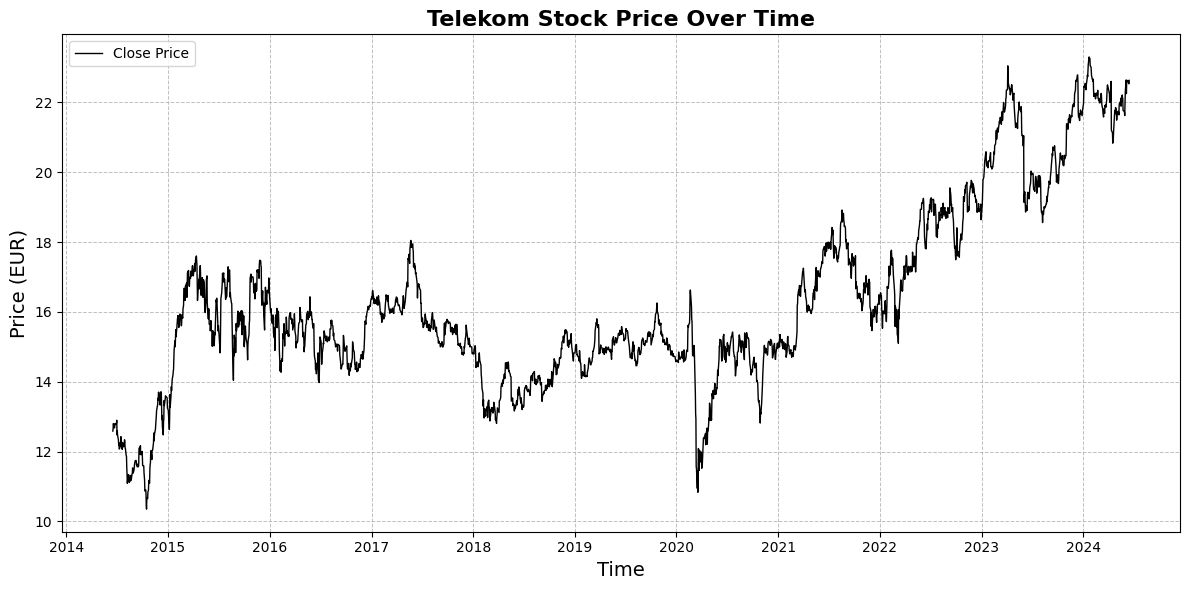

In [40]:
df = pd.read_csv(
    '/Users/lapomazzari/Desktop/TUM Mathematical Finance/Kurse/SS25/'
    'Financial Mathematics 2/Grade Bonus Task/'
    'Telekom.csv', sep=',', index_col='Date'
)

df.index = pd.to_datetime(df.index)

plt.figure(figsize=(12, 6))

plt.plot(df['Close'], color='black', linewidth=1, label='Close Price')

plt.title('Telekom Stock Price Over Time', fontsize=16, weight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Price (EUR)', fontsize=14)
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.8)
plt.legend()
plt.tight_layout()

plt.show()

Next, we compute the **log-returns** of the Telekom stock based on the daily closing prices. The log-return at time step $i$ is defined as
$$Y_i = \log\left(\frac{P_i}{P_{i-1}}\right).$$

Log-returns are widely used in financial modeling because of their desirable properties — notably, time additivity, and the fact that they tend to be approximately normally distributed over short intervals.

Again, we visualize their evolution over the full 10-year period to gain some insight into the volatility and the dynamic of the asset.

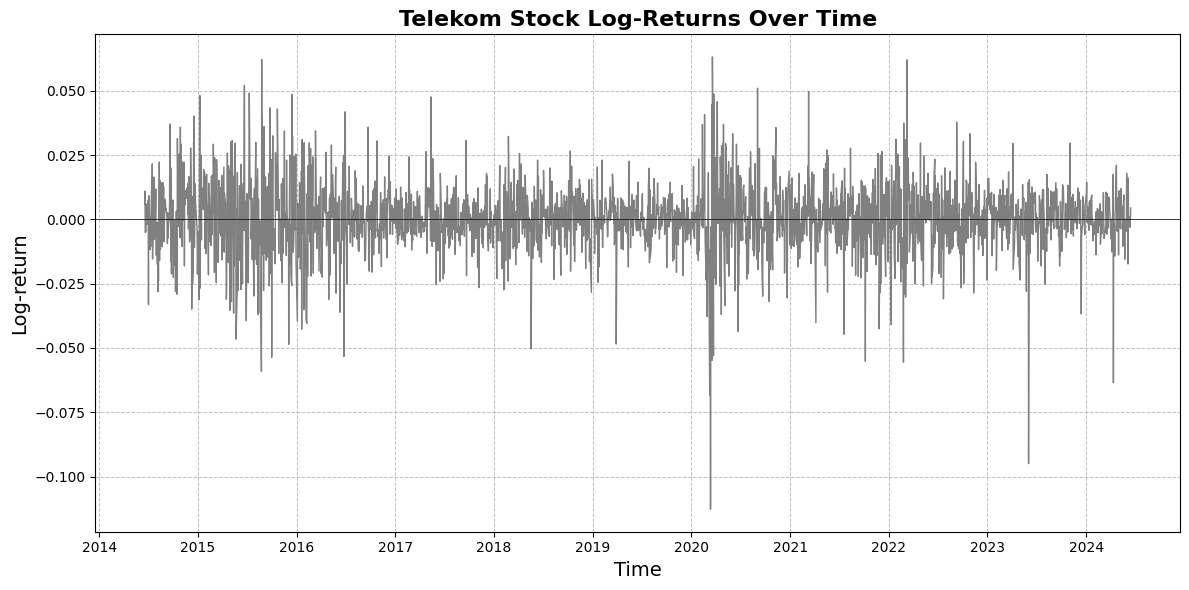

In [41]:
df = df.copy()

# Make sure 'Close' is numeric
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

closing_prices = df['Close']

log_returns = returns = np.log(closing_prices / closing_prices.shift(1)).dropna()

df['Log_Returns'] = log_returns

plt.figure(figsize=(12,6))

plt.plot(log_returns, color='grey', linewidth=1)

plt.title('Telekom Stock Log-Returns Over Time', fontsize=16, weight='bold')
plt.xlabel('Time', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.ylabel('Log-return', fontsize=14)
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.8)
plt.tight_layout()

plt.show()


To capture the key statistical features of the log returns, we report standard summary metrics such as the mean, standard deviation, minimum, maximum, and selected quantiles.

In [42]:
mean = log_returns.mean()
var = log_returns.var()
std = log_returns.std()
min_return = log_returns.min() 
max_return = log_returns.max()
q1 = log_returns.quantile(0.25) 
q2 = log_returns.quantile(0.50)  
q3 = log_returns.quantile(0.75)  

summary_stats = pd.DataFrame({
    "Statistic": ["Mean", "Variance", "Standard Deviation", "Minimum", "Maximum",
    "First Quartile (Q1)", "Median (Q2)", "Third Quartile (Q3)"],
    "Value": [mean, var,  std, min_return, max_return, q1, q2, q3]
})

print(summary_stats)

             Statistic     Value
0                 Mean  0.000231
1             Variance  0.000179
2   Standard Deviation  0.013379
3              Minimum -0.112673
4              Maximum  0.063141
5  First Quartile (Q1) -0.005909
6          Median (Q2)  0.000000
7  Third Quartile (Q3)  0.007092


## Task 2

In this section, we aim to fit the classical Black-Scholes model to the historical price data of the Telekom stock. This involves estimating the model's core parameters, namely the drift and volatility by using the empirical log-returns derived from the time series. We assume that prices follow a **geometric Brownian motion**, given by the stochastic differential equation:

$$
dP_t = \mu P_t \, dt + \sigma P_t \, dW_t
$$

where $P_t$ is the stock price at time $t$, $\mu$ is the drift (constant), $\sigma$ is the volatility (constant) and $W_t$ is a standard Brownian motion. Let $Y_i$ denote the $i$-th log-return, and let $\hat{Y}$ be the empirical mean computed above. According to Itô’s lemma, the dynamics of the logarithmic stock price $\log(P_t)$ under the Black-Scholes model are governed by the stochastic differential equation  
$$
d \log(P_t) = \left( \mu - \frac{1}{2}\sigma^2 \right) dt + \sigma\, dW_t.
$$  
This continuous-time representation implies that, in a discretized setting, the log-returns $Y_i$ can be interpreted as i.i.d. realizations of a normally distributed random variable with mean $(\mu - \frac{1}{2}\sigma^2)\Delta$ and variance $\sigma^2 \Delta$, i.e.,
$$
Y_{i+1} = \log(P_{t_{i+1}}) - \log(P_{t_{i}}) \sim \mathcal{N}\left((\mu - \frac{1}{2}\sigma^2)\Delta, \sigma^2 \Delta \right),
$$
where $\Delta$ denotes the time step size of the discretized time grid. This statistical interpretation allows us to estimate the model parameters $\hat{\mu}$ and $\hat{\sigma}$ from historical data. Using the sample mean and variance of the log-returns, we obtain
$$\hat{\sigma} = \sqrt \frac{\mathbb{Var}(Y)}{\Delta} \quad \text{and} \quad \hat{\mu}= \frac{\hat{Y}}{\Delta} + \frac{1}{2}\, \hat{\sigma}^2.
$$
Since the log-returns $Y_i$ are computed from daily price data, both the sample mean $\hat{\mu}$ and standard deviation $\hat{\sigma}$ are naturally expressed in daily units. As we model the price dynamics on a daily time grid, there is no need to annualize these parameters. The Black-Scholes framework remains valid as long as the time variable and model parameters are expressed in consistent units — in this case, trading days. Under the assumption that log-returns are independent and identically distributed, this discretized setup allows for a direct estimation of $\hat{\mu}$ and $\hat{\sigma}$ from the data, with $\Delta = 1$ representing one trading day.

Building on the Black-Scholes framework, we now simulate stock price paths over the observed period using the model's closed-form discrete-time solution:
$$
P_{t+\Delta t} = P_t \cdot \exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} \cdot Z\right),
$$
where $\Delta t = 1$ reflects one trading day, and $Z \sim \mathcal{N}(0,1)$ are independent standard normal random variables. This formulation allows us to generate realistic price trajectories that reflect both the deterministic drift and the stochastic volatility inherent in the model. Using Monte Carlo simulation, we generate multiple price trajectories by repeatedly sampling random increments from the distribution implied by the Black-Scholes model. Each path reflects one possible evolution of the stock price under the assumed dynamics. As the number of simulated paths $M$ increases, the influence of random fluctuations diminishes, and the average path more clearly reflects the underlying drift component $\mu$.

The following plots illustrate the effect of increasing $M$ on the simulated average price paths, demonstrating convergence toward the expected price trajectory as the sample size grows.




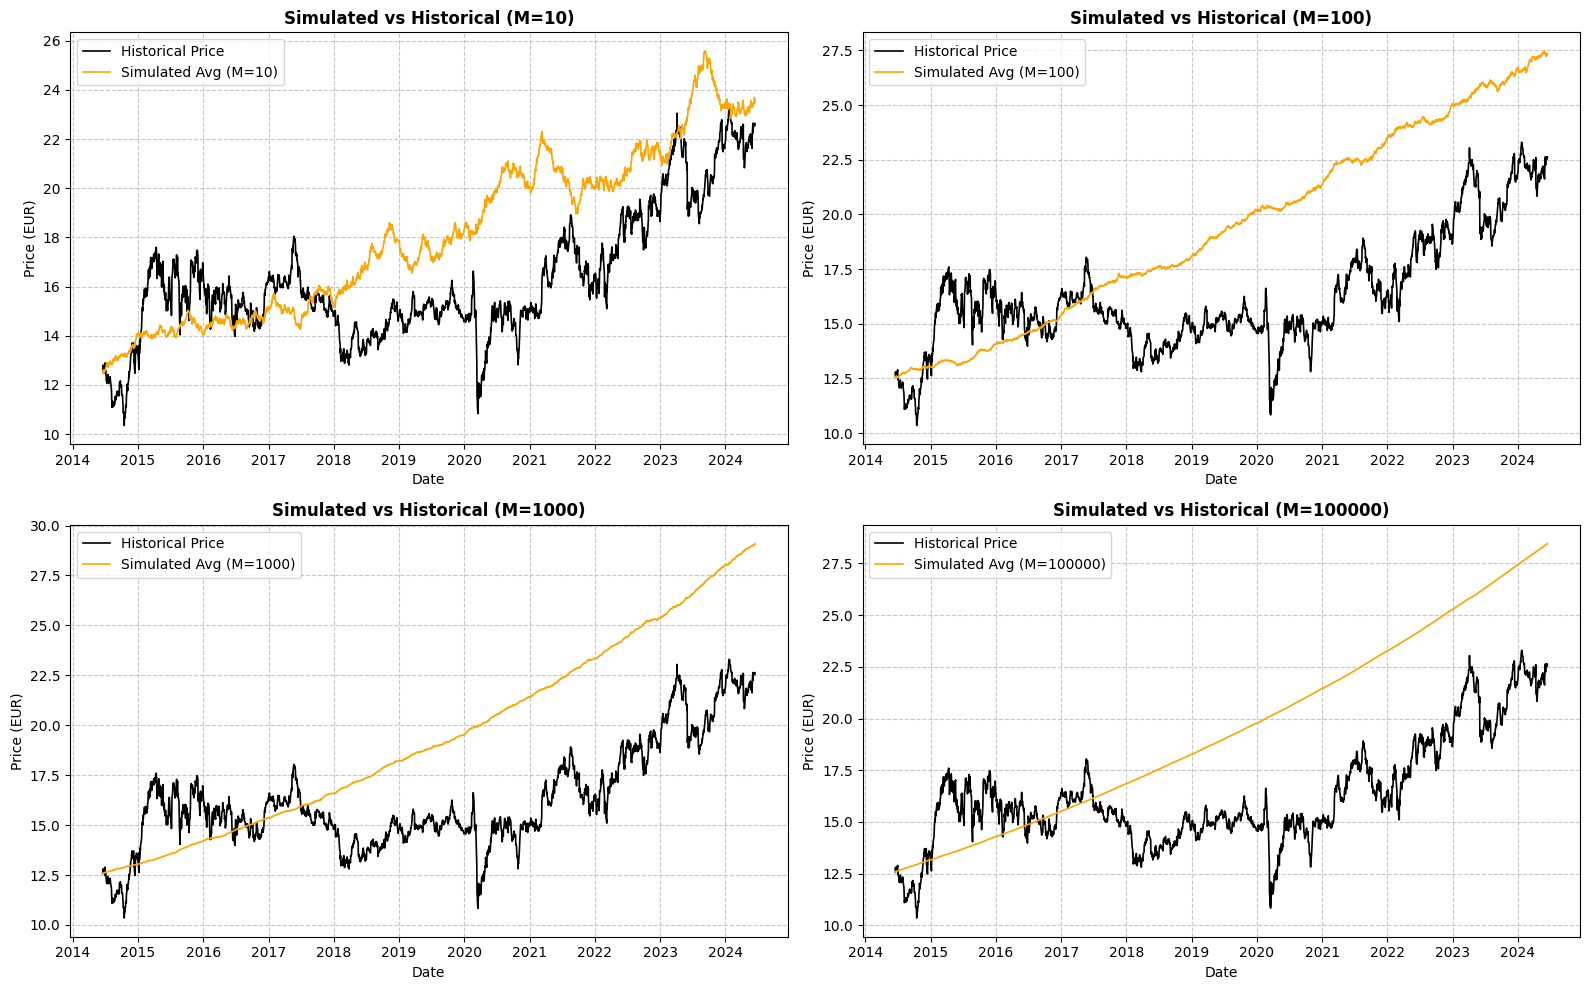

In [43]:
# Initial settings
P0 = df['Close'].iloc[0]  # historical initial price
returns = log_returns.values  # remove first NaN
N = len(returns)  # number of time steps (days)

# Estimated daily parameters
sigma = std
drift = mean + .5 * sigma**2  # corrected daily drift for GBM

step = 1  # time step = 1 trading day

# Simulations with increasing number of paths
M_values = [10, 100, 1000, 100000]
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

for i, M in enumerate(M_values):
    # Generate all Brownian increments at once
    Z = np.random.normal(0, 1, size=(M, N))

    # Compute log-returns and cumulative log-prices
    log_returns = (drift - .5 * sigma**2) * step + sigma * np.sqrt(step) * Z
    log_price_paths = np.cumsum(log_returns, axis=1)
    log_price_paths = np.hstack([np.zeros((M, 1)), log_price_paths])  # initial log(P0)

    # Convert to price paths
    price_paths = P0 * np.exp(log_price_paths)

    # Average over all paths
    average_path = price_paths.mean(axis=0)

    # Plot historical and simulated average path
    axs[i].plot(df.index, df['Close'], color='black', linewidth=1.2, label='Historical Price')
    axs[i].plot(df.index, average_path, color='orange', linewidth=1.2, label=f'Simulated Avg (M={M})')
    axs[i].set_title(f'Simulated vs Historical (M={M})', fontsize=12, fontweight='bold')
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Price (EUR)')
    axs[i].grid(True, linestyle='--', alpha=0.7)
    axs[i].legend()

plt.tight_layout()
plt.show()


By averaging over all simulated paths, the randomness contributed by the diffusion term smoothes out, allowing the underlying drift component of the Black-Scholes model to become clearly visible. This demonstrates how the expected trend drives the price evolution when stochastic fluctuations are averaged out.

## Task 3

Bonus Certificates are structured financial products that provide investors with the opportunity for enhanced returns compared to directly holding the underlying asset, usually a stock. These products blend characteristics of traditional investments and options, offering a minimum guaranteed payout (the bonus level) as long as the underlying asset’s price does not fall below a predefined barrier level during the certificate’s lifetime.

In the following, we consider the payoff profile of a Bonus Certificate as an illustrative example. We assume a barrier level $H = 15$ and a bonus level $B=30$. The underlying asset price at maturity $P_T$ is varied between 0 and 40 to visualize the corresponding payoff of the certificate. This visualization highlights how the payoff depends on whether the barrier is breached during the lifetime of the derivative and the position of the terminal price relative to the bonus level.

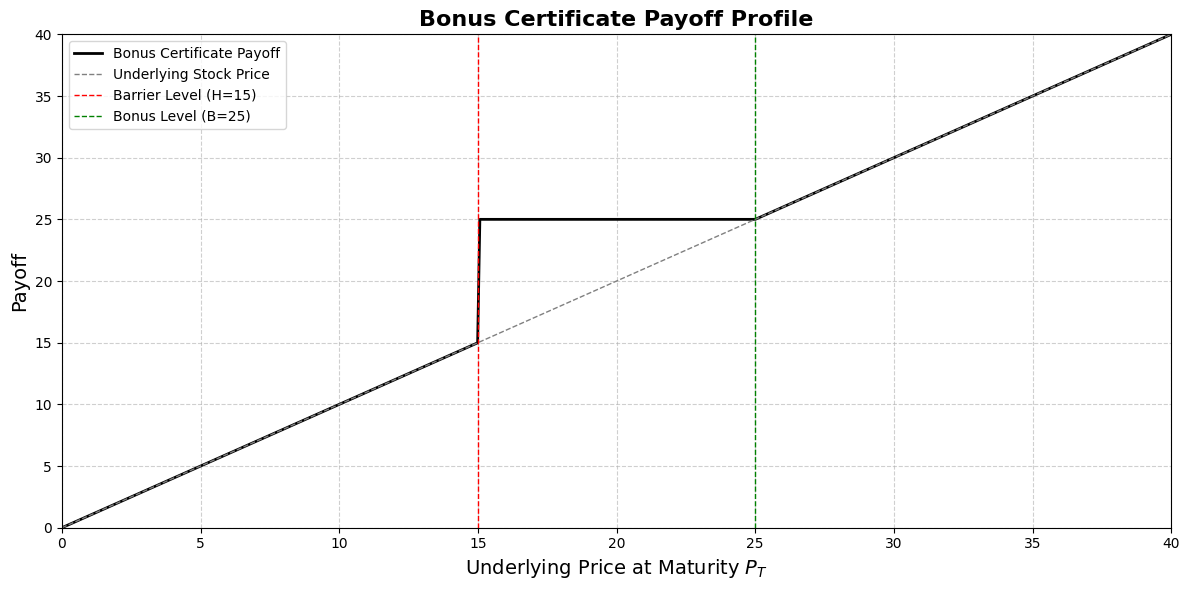

In [44]:
H = 15 # Barrier
B = 25 # Bonus level

PT = np.linspace(0, 40, 500)

payoff = np.where(PT <= H, PT, np.where(PT <= B, B, PT))

plt.figure(figsize=(12, 6))

plt.plot(PT, payoff, label='Bonus Certificate Payoff', color='black', linewidth=2)
plt.plot(PT, PT, label='Underlying Stock Price', color='gray', linestyle='--', linewidth=1)

plt.axvline(H, color='red', linestyle='--', linewidth=1, label=f'Barrier Level (H={H})')
plt.axvline(B, color='green', linestyle='--', linewidth=1, label=f'Bonus Level (B={B})')
plt.title('Bonus Certificate Payoff Profile', fontsize=16, weight = 'bold')
plt.xlabel('Underlying Price at Maturity $P_T$', fontsize=14)
plt.ylabel('Payoff', fontsize=14)
plt.xlim(0, 40)
plt.ylim(0, 40)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Investors may be drawn to Bonus Certificates because they offer the potential for higher returns compared to directly holding the underlying asset - especially when the stock price stays between the barrier and the bonus level. These instruments provide conditional downside protection: as long as the barrier is not breached, the investor is protected against moderate losses. In addition, if the underlying remains above the barrier at maturity, the investor receives a fixed bonus payout, which can exceed the return from simply holding the asset. This structure combines elements of capital preservation with the opportunity for enhanced yield in sideways or moderately bullish markets.



However, the main risk lies in the (possible) high volatility of the underlying asset’s price. Due to significant price fluctuations, there is an increased probability that the price will fall below the safety threshold at some point during the term. If the barrier is breached, the bonus mechanism expires, and the investor loses the protection, facing the full downside risk of the underlying.

This barrier risk is a key concern, as it can significantly affect the certificate’s payoff. Additionally, because Bonus Certificates are structured and more complex financial products, there are potential liquidity risks - it may be harder to sell them quickly or at a fair price compared to more straightforward investments.

In summary, while Bonus Certificates can be appealing for enhanced returns with partial protection, investors must carefully consider the volatility-driven barrier risk and the complexities that might affect liquidity.

## Task 4

The payoff of a Bonus Certificate depends on the price of the corresponding underlying at Maturity $T$ **and** on whether the barrier $H$ was breached at any time during its lifetime. More precisely, given a predetermined Bonus Level $B$, the payoff of the Bonus Certificate equals B if and only if the barrier $H$ was not touched or breached during the product's lifetime and the terminal price $P_T \leq B$. In all other cases the payoff will simply be the terminal price $P_T$ itsself. We can formalize this by expressing the payoff $D$ as
$$D = B \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:;\: P_T \leq B\:\}} + P_T \cdot \mathbf{1}_{{\{\:\min_{t \in [0,T]} P_t > H\:;\: P_T \leq B\:\}}^c},$$ 
which is equivalent to $$\begin{align*} D &= B \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:;\: P_T \leq B\:\}} + P_T - P_T \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:;\: P_T \leq B\:\}}\\
\Leftrightarrow D &= (B - P_T) \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:;\: P_T \leq B\:\}} + P_T \\
\Leftrightarrow D &= (B - P_T)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} + P_T
\end{align*}$$where $(B - P_T)^+ = \max\{B-P_T, 0 \}$. We can therefore replicate the payoff of the Bonus Certificate by a long Down-and-out put option with Strike $B$ and the underlying asset $P_t$. 

## Task 5

Our objective is now to find a fair value for the Bonus Certificate. Because the market model is complete, the price of any contingent claim coincides with the price of its replicating portfolio. We will use this fact to price the Bonus Certificate.
$$
\begin{align*} V_0^D &= \mathbb{E}_{\mathbb{\tilde{Q}}}\left[e^{-r  T} D \right] = \mathbb{E}_{\mathbb{\tilde{Q}}}\left[e^{-r \cdot T} (B - P_T)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} + e^{-rT}P_T\right]\\
&= \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} (B - P_T)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] + \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-rT} P_T \right]\\
&= \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} (B - P_T)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] + P_0.
\end{align*}$$
Now, since $$ (B-P_T)^+ = (P_T - B)^+ - (P_T - B)$$ we further obtain that
$$
\begin{align*} V_0^D &= \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} \left((P_T - B)^+ - (P_T - B)\right) \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] + P_0 \\
&= \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} (P_T - B)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] - \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} (P_T - B)\cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] + P_0\\
&= DOC(P_0,0) + e^{-rT} B Q^{(2)} - P_0(Q^{(1)}-1) \\
&= C(P_0,0) - KOD(P_0,0) + e^{-rT} B Q^{(2)} - P_0(Q^{(1)}-1),
\end{align*}$$
where $C(P_0,0)$ denotes the vanilla call option price at $t=0$, $KOD(P_0,0)$ the knockout discount, by which the knockout barrier $H$ lowers the price and $Q^{(1,2)}$ as given on the task sheet.

We now explicitely compute the price of a Bonus Certificate on the Telekom stock with $P_0$ equal to the price quoted on 14.06.2024, barrier level 16, bonus level 24 and maturity of 1 year. We will use the market parameters from above and since we are valuating with respect to the risk-neutral measure, we will use the risk-free rate $r$ as drift. 

In [ ]:
P0 = df.at['14-06-2024', 'Close']
H = 16 # barrier
B = 24 # bonus
T = 252 # Maturity equal to 1 trading year

In [46]:
def Call(P0, r, sigma, T, K):
    a = np.log(P0 / K) + (r + .5 * sigma**2) * T
    c = sigma * np.sqrt(T)
    d1 = a / c
    d2 = d1 - c
    call_price = P0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

def KOD(P0, r, sigma, T, K, H):
    lam = (r - .5 * sigma**2)
    x1 = (np.log(H**2 / (P0 * K)) + (r + .5 * sigma**2) * T) / (sigma * np.sqrt(T))
    x2 = x1 - sigma * np.sqrt(T)

    term1 = P0 * (H / P0) ** (2 + 2 * lam / sigma**2) * norm.cdf(x1)
    term2 = K * np.exp(-r * T) * (H / P0) ** (2 * lam / sigma**2) * norm.cdf(x2)
    
    return term1 - term2

def DOC(P0, r, sigma, T, K, H):
    vanilla_call = Call(P0, r, sigma, T, K)
    knock_out_discount = KOD(P0, r, sigma, T, K, H)
    return vanilla_call - knock_out_discount

def option_price(P0, r, sigma, T, B, H):
    d1 = (np.log(P0/H) + (r + .5 * sigma**2) * T) / (sigma * np.sqrt(T))
    q1 = norm.cdf(d1) - np.exp(-(2*(r + .5 * sigma**2) * np.log(P0/H))/ sigma**2) * norm.cdf((-np.log(P0/H) + (r + .5 * sigma**2) * T)/sigma*np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    q2 = norm.cdf(d2) - np.exp(-(2*(r - .5 * sigma**2)*np.log(P0/H))/sigma**2) * norm.cdf((-np.log(P0/H) + (r - .5 * sigma**2) * T)/sigma*np.sqrt(T))
    price = DOC(P0, r, sigma, T, B, H) + np.exp(-r * T) * B * q2 - P0*(q1 - 1)
    return price

analytical_price = option_price(P0, r, sigma, T, B, H)
print(analytical_price)

22.6299991607666


## Task 6

To confirm the pricing formula derived analytically in Task 5, we use a Monte Carlo simulation approach. The idea is to simulate multiple price paths of the underlying asset under the risk-neutral measure and evaluate the expected discounted payoff of the Bonus Certificate. Therefore, this time, we simulate **future price paths** to approximate the option price numerically.

We simulate 100,000 price paths of the underlying asset over a one-year horizon using the geometric Brownian motion model. At each timestep, we monitor whether the barrier $H$ has been breached.

To achieve computational efficiency, we employ vectorized NumPy operations to:

1. Simulate all Brownian increments simultaneously.

2. Track barrier breaches for each path.

3. Calculate final *discounted* payoffs accordingly.

Additionally, we use antithetic variables to reduce the variance of our Monte Carlo estimator, improving the accuracy and convergence speed of the price estimate without increasing the number of simulations.

The price of the Bonus Certificate is then estimated as the average discounted payoff across all simulated paths. This approach allows us to approximate the fair value of the product under the risk-neutral measure efficiently and with high numerical stability.

In [47]:
def simulate_paths_with_barrier_antithetic(P0, drift, sigma, T, steps, H, M):
    dt = T / steps
    Z = np.random.normal(size=(M, steps))
    Z_antithetic = -Z

    def simulate(Z):
        increments = (drift - .5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
        log_P = np.cumsum(increments, axis=1)
        log_P = np.hstack([np.full((M, 1), np.log(P0)), np.log(P0) + log_P])
        P = np.exp(log_P)
        breached = (P <= H).any(axis=1)
        PT = P[:, -1]
        return breached, PT

    breached1, PT1 = simulate(Z)
    breached2, PT2 = simulate(Z_antithetic)

    breached = np.concatenate([breached1, breached2])
    PT = np.concatenate([PT1, PT2])

    return breached, PT

def monte_carlo_vectorized_antithetic(P0, drift, sigma, T, steps, H, B, r, M=10000):
    # Half the number of random paths, but each one gives 2 results
    breached, PT = simulate_paths_with_barrier_antithetic(P0, drift, sigma, T, steps, H, M)

    put_payoff = np.maximum(B - PT, 0)
    payoffs = np.where(breached, PT, PT + put_payoff)
    discounted_payoffs = np.exp(-r * T) * payoffs

    return discounted_payoffs.mean()

monte_carlo_price = monte_carlo_vectorized_antithetic(P0, r, sigma, T, 1000, H, B, r)

print(monte_carlo_price)

22.631427473796602


To validate the analytical pricing formula, we compared it to the result obtained via Monte Carlo simulation. The absolute error and relative error between the two methods were calculated as follows:

In [48]:
def compare_prices(true_value, estimated_value, label="Price"):
    abs_error = abs(true_value - estimated_value)
    rel_error = abs_error / abs(true_value) * 100 if true_value != 0 else float('inf')
    
    print(f"{label}:")
    print(f"  Analytical value  = {true_value:.6f}")
    print(f"  Monte Carlo value = {estimated_value:.6f}")
    print(f"  Absolute error    = {abs_error:.6f}")
    print(f"  Relative error    = {rel_error:.4f}%\n")

compare_prices(analytical_price, monte_carlo_price, label="Comparison of results")


Comparison of results:
  Analytical value  = 22.629999
  Monte Carlo value = 22.631427
  Absolute error    = 0.001428
  Relative error    = 0.0063%



The small error observed confirms that the Monte Carlo method provides a close numerical approximation to the theoretical price. Such small deviations are normal due to the randomness of simulations. The result supports the correctness of the analytical pricing formula derived earlier. If higher accuracy is needed, the simulation can be refined by increasing the number of simulated paths or applying variance reduction techniques.

## Task 7

We now simulate the evolution of the underlying price and the payoff of the Bonus Certificate under the physical probability measure. This allows us to investigate the risk characteristics of the instrument and compare them directly with those of the underlying asset. Specifically, we compare the distributional properties of the terminal asset price $P_T$​ and the corresponding certificate payoff. For both variables, we compute key summary statistics: the mean, variance, skewness, kurtosis, and the 5% quantile (i.e., Value-at-Risk at 95% confidence level).

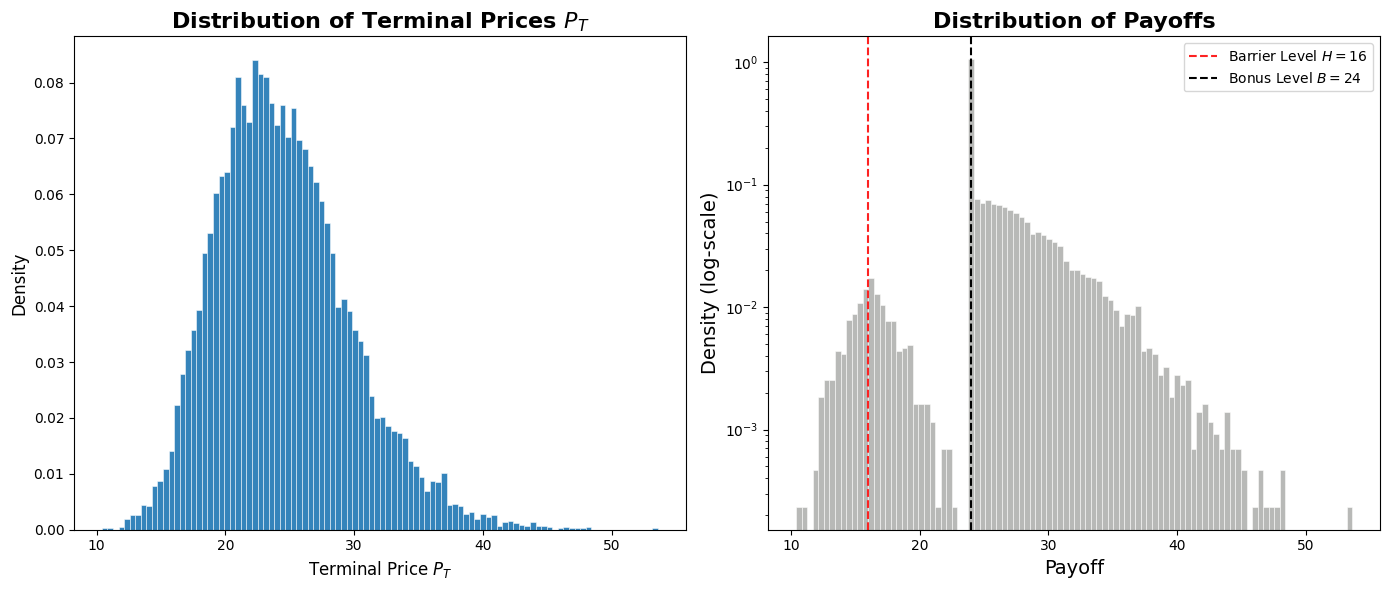

Terminal Prices Statistics:
--------------------------
Mean                : 24.5020
Variance            : 27.1280
Standard Deviation  : 5.2085
Skewness            : 0.6463
Excess Kurtosis     : 0.6699
Max                 : 53.5923
Min                 : 10.4113
5% Quantile (VaR)   : 17.0206

Payoffs Statistics:
------------------
Mean                : 25.8497
Variance            : 18.2183
Standard Deviation  : 4.2683
Skewness            : 0.6879
Excess Kurtosis     : 2.9873
Max                 : 53.5923
Min                 : 10.4113
5% Quantile (VaR)   : 18.3235



In [49]:
def simulate_paths_physical(P0, drift, sigma, T, steps, H, B, M=10000):
    dt = T / steps

    # Simulate all Brownian motion increments at once
    Z = np.random.normal(size=(M, steps))
    increments = (drift - .5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    # Cumulative log-prices and prepend log(P0)
    log_paths = np.cumsum(increments, axis=1)
    log_paths = np.hstack([np.full((M, 1), np.log(P0)), log_paths + np.log(P0)])

    # Convert to price paths
    P_paths = np.exp(log_paths)
    PT = P_paths[:, -1]  # Final price at maturity

    # Barrier check: was H ever breached?
    breached = (P_paths <= H).any(axis=1)

    # Payoffs
    put_payoff = np.maximum(B - PT, 0)
    payoffs = np.where(breached, PT, PT + put_payoff)

    return PT, payoffs

PT, payoffs = simulate_paths_physical(P0, drift, sigma, 252, 10000, 16, 24, M=10000)

plt.figure(figsize=(14, 6))

# 1. Distribution of Terminal Prices P_T
plt.subplot(1, 2, 1)
plt.hist(PT, bins=100, color='#1f77b4', alpha=0.9, density=True, edgecolor='white', linewidth=0.4)
plt.title('Distribution of Terminal Prices $P_T$', fontsize=16, weight='bold')
plt.xlabel('Terminal Price $P_T$', fontsize=12)
plt.ylabel('Density', fontsize=12)

# 2. Distribution of Payoffs
plt.subplot(1, 2, 2)
plt.hist(payoffs, bins=100, color="#B1B2AF", alpha=0.9, density=True, edgecolor='white', linewidth=0.4)
plt.title('Distribution of Payoffs', fontsize=16, weight='bold')
plt.xlabel('Payoff', fontsize=14)
plt.ylabel('Density (log-scale)', fontsize=14)
plt.axvline(x=16, color="#FD2222", linestyle='--', linewidth=1.5, label='Barrier Level $H=16$')
plt.axvline(x=24, color="#000000", linestyle='--', linewidth=1.5, label='Bonus Level $B=24$')
plt.yscale('log')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

def print_stats(name, data):
    stats = {
        "Mean": np.mean(data),
        "Variance": np.var(data),
        "Standard Deviation": np.std(data),
        "Skewness": skew(data),
        "Excess Kurtosis": kurtosis(data),  # excess kurtosis (normal=0)
        "Max": np.max(data),
        "Min": np.min(data),
        "5% Quantile (VaR)": np.quantile(data, 0.05),
    }
    
    print(f"{name} Statistics:")
    print("-" * (len(name) + 11))
    for stat_name, value in stats.items():
        print(f"{stat_name:<20}: {value:.4f}")
    print()

print_stats("Terminal Prices", PT)
print_stats("Payoffs", payoffs)

The results of the simulation reveal distinct differences between the underlying asset and the payoff of the structured product:

The distribution of the terminal asset price $P_T$ is continuous and exhibits positive skewness, as expected from a geometric Brownian motion process. Its kurtosis is moderate, consistent with the thin tails of the lognormal distribution.

In contrast, the distribution of the certificate's payoff is highly irregular. Due to the non-linear nature of the payoff function (influenced by the barrier and bonus level), the distribution is discontinuous and clustered around key values.

We observe a concentration of mass at the bonus level $B$, reflecting scenarios in which the barrier was not breached and the investor received the bonus.

The skewness and kurtosis of the payoff distribution are significantly higher, showing that the payoff is more asymmetric and more prone to extreme outcomes than the terminal price itself.

Notably, the 5% quantile (Value-at-Risk) of the payoff distribution is substantially higher than that of the underlying asset. This reflects the downside protection provided by the barrier feature of the Bonus Certificate, which cushions losses in adverse scenarios.

These differences highlight the value added by structured products in tailoring risk-return profiles, but they also underline the complexity in analyzing and pricing such instruments.